##### Copyright 2026 Google LLC.

In [1]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Code Execution

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Code_Execution.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>


The Gemini API [code execution](https://ai.google.dev/gemini-api/docs/code-execution) feature enables the model to generate and run Python code based on plain-text instructions that you give it, and even output graphs. It can learn iteratively from the results until it arrives at a final output.

This notebook is a walk through:
* Understanding how to start using the code execution feature with Gemini API
* Learning how to use code execution on single Gemini API calls
* Running scenarios using local files (or files uploaded to the Gemini File API) via File I/O
* Using code execution on chat interactions
* Performing code execution on multimodal scenarios

## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai).

In [2]:
# %pip install -q -U "google-genai>=2.9.0"

### Setup your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Authentication.ipynb) for an example.

In [3]:
# === AUTO-PATCH: Replace Colab userdata with env vars ===
import os
import sys
import types

# Ensure 'google' module exists
if 'google' not in sys.modules:
    import google
    if 'google' not in sys.modules:
        sys.modules['google'] = types.ModuleType('google')

google_mod = sys.modules['google']

# Create colab submodule if needed
if not hasattr(google_mod, 'colab'):
    colab_mod = types.ModuleType('google.colab')
    google_mod.colab = colab_mod
    sys.modules['google.colab'] = colab_mod
else:
    colab_mod = google_mod.colab

# Create userdata submodule
userdata_mod = types.ModuleType('google.colab.userdata')
def _get(key): return os.environ.get(key, '')
userdata_mod.get = _get
colab_mod.userdata = userdata_mod
sys.modules['google.colab.userdata'] = userdata_mod

os.environ['GEMINI_API_KEY'] = os.environ.get('GEMINI_API_KEY', '')
print('Colab userdata patched ✅')

Colab userdata patched ✅


In [4]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

### Initialize SDK client

With the new SDK you now only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.

In [5]:
from google import genai

client = genai.Client(api_key=GEMINI_API_KEY)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


### Choose a model

Now select the model you want to use in this guide, either by selecting one in the list or writing it down. Keep in mind that some models, like the 2.5 ones are thinking models and thus take slightly more time to respond (cf. [thinking notebook](./Get_started_thinking.ipynb) for more details and in particular learn how to switch the thiking off).

For more information about all Gemini models, check the [documentation](https://ai.google.dev/gemini-api/docs/models/gemini) for extended information on each of them.

In [6]:
MODEL_ID = "gemini-3.6-flash" # @param ["gemini-2.5-flash-lite", "gemini-2.5-flash", "gemini-2.5-pro", "gemini-2.5-flash-preview", "gemini-3-flash-preview", "gemini-3.5-flash-lite", "gemini-3.1-pro-preview", "gemini-3.6-flash"] {"allow-input":true, isTemplate: true}

## Helper function

When using code execution as a tool, the model returns a list of parts including `text`, `executable_code`, `execution_result`, and `inline_data` parts. Use the function below to help you visualize and better display the code execution results. Here are a few details about the different fields of the results:

* `text`: Inline text generated by the model.
* `executable_code`: Code generated by the model that is meant to be executed.
* `code_execution_result`: Result of the `executable_code`.
* `inline_data`: Inline media generated by the model.

In [7]:
from IPython.display import Image, Markdown, Code, HTML

def display_code_execution_result(response):
  for part in response.candidates[0].content.parts:
    if part.text is not None:
      display(Markdown(part.text))
    if part.executable_code is not None:
      code_html = f'<pre style="background-color: green;">{part.executable_code.code}</pre>' # Change code color
      display(HTML(code_html))
    if part.code_execution_result is not None:
      display(Markdown(part.code_execution_result.output))
    if part.inline_data is not None:
      display(Image(data=part.inline_data.data, width=800, format="png"))
    display(Markdown("---"))

## Use `code_execution` with a single call

When initiating the model, pass `code_execution` as a `tool` to tell the model that it is allowed to generate and run code.

In [8]:
from google.genai import types

prompt = """
    What is the sum of the first 50 prime numbers?
    Generate and run code for the calculation, and make sure you get all 50.
"""

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        tools=[types.Tool(
            code_execution=types.ToolCodeExecution
            )]
        )
    )

display_code_execution_result(response)

---

The first 50 primes are: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229]
Number of primes found: 50
Sum of the first 50 primes: 5117


---

The sum of the first 50 prime numbers is **5,117**.

To find this, I used a script to identify the first 50 prime numbers starting from 2 and then summed them:

1.  **The Primes:** 2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229.
2.  **The Sum:** 5,117.

---

## Code execution with File I/O

The dataset you will use in this guide comes from the [StatLib](http://lib.stat.cmu.edu/datasets/) from the [Department of Statistics](https://www.cmu.edu/dietrich/statistics-datascience/index.html) at [Carnegie Mellon University](http://www.cmu.edu/). It is made available by the [`scikit-learn`](https://scikit-learn.org) under the 3-Clause BSD license.

It provides 20k information on various blocks in Californina, including the location (longitute/lattitude), average income,
housing average age, average rooms, average bedrooms, population,
average occupation.

Here's a breakdown of the columns and what the attributes represent:
* MedInc:        median income in block group
* HouseAge:      median house age in block group
* AveRooms:      average number of rooms per household
* AveBedrms:     average number of bedrooms per household
* Population:    block group population
* AveOccup:      average number of household members
* Latitude:      block group latitude
* Longitude:     block group longitude

**Note**: Code execution functionality works best with a `.csv` or `.txt` file.


In [9]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)
california_housing.frame.to_csv('houses.csv', index=False)

In [10]:
# Read the CSV file into a pandas DataFrame
houses_data = pd.read_csv('houses.csv', nrows=5000) # only keeping the first 5000 entries to keep the request light (still 500k tokens). Use pro models to ingest the full dataset.
houses_data.to_csv('houses.csv', index=False)
houses_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
# Upload diving_data.csv file using the File API
houses_file = client.files.upload(
    file='houses.csv',
    config=types.FileDict(display_name='Blocks Data')
)

print(f"Uploaded file '{houses_file.display_name}' as: {houses_file.uri}")

Uploaded file 'Blocks Data' as: https://generativelanguage.googleapis.com/v1beta/files/fh25vtdq6dz9


Let's try several queries about the dataset that you have. Starting off, it would be interesting to see the most expensive blocks and check wether there's abnomal data.

---

Anomalous blocks found at indices: [3486]


---

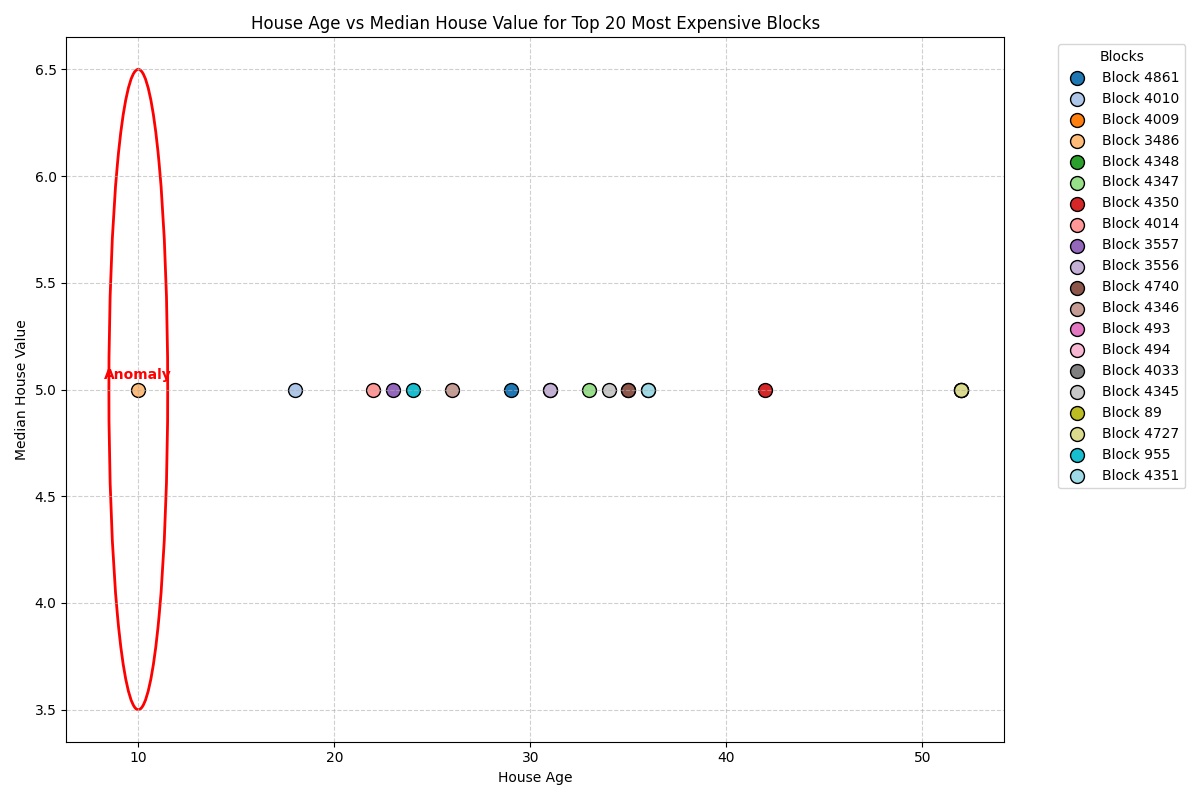

---

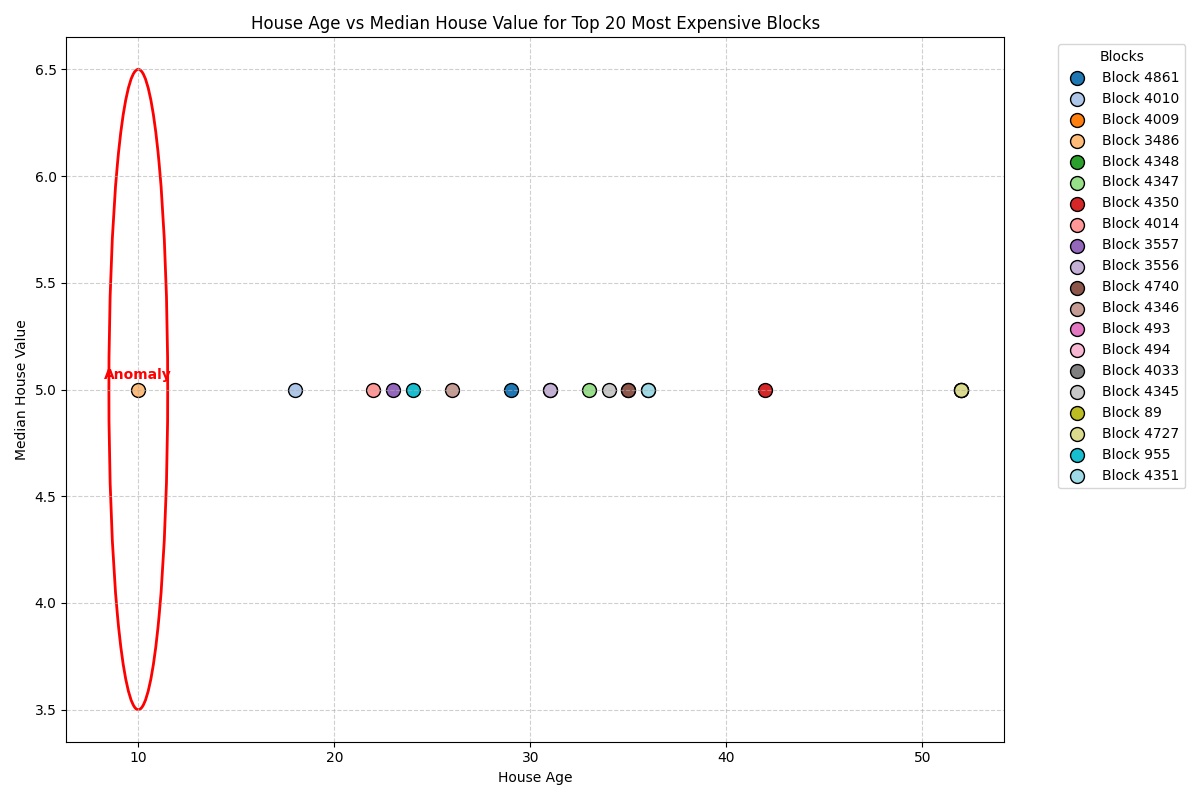

---

---

In [12]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        "This dataset provides information on various blocks in Californina.",
        "Generate a scatterplot comparing the houses age with the median house value for the top-20 most expensive blocks.",
        "Use each black as a different color, and include a legend of what each color represents.",
        "Plot the age as the x-axis, and the median house value as the y-axis.",
        "In addition, point out on the graph which points could be anomalies? Circle the anomaly in red on the graph."
        "Then save the plot as an image file and display the image.",
        houses_file
    ],
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

display_code_execution_result(response)

Moving forward with the data investigation, you can now analyze data variance in the dataset:

---

Variance of MedHouseVal for houses between 15 and 25 years old: 1.0802898302341137


---

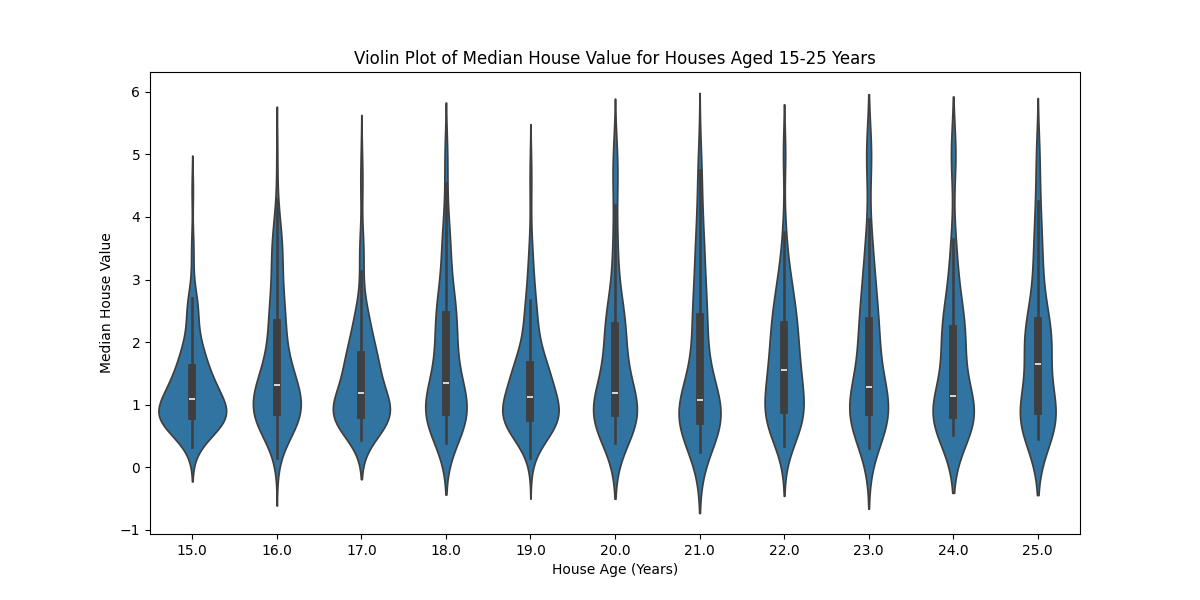

---

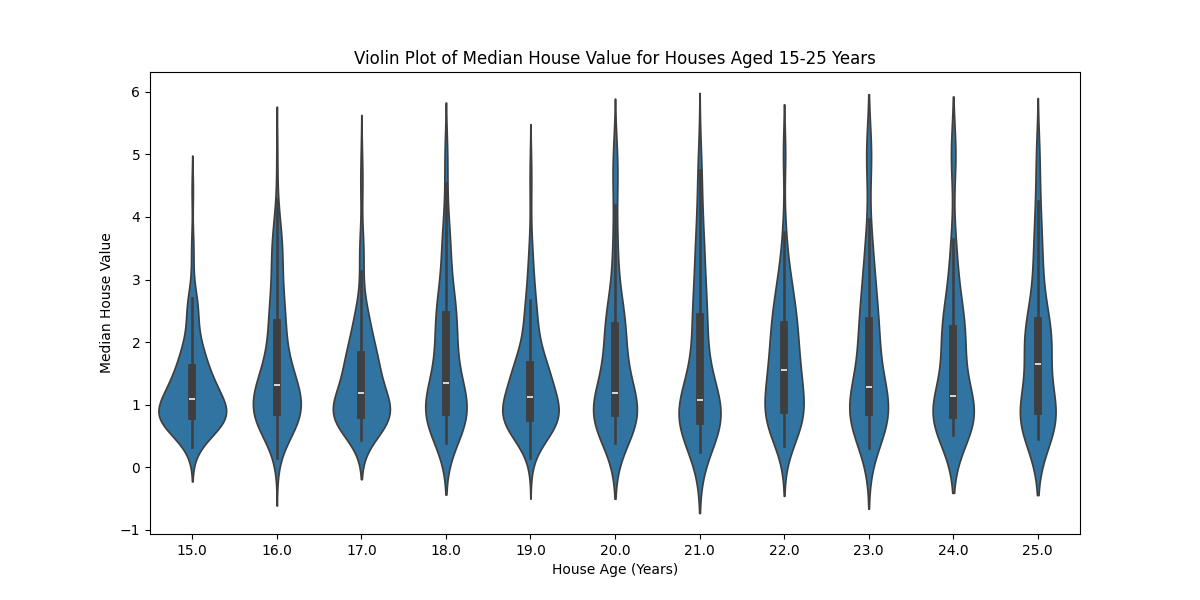

---


The variance of the median house price for houses between 15 and 25 years old is approximately **1.08**.

I have created a violin plot showing the distribution of median house values for each house age within this range. The plot has been saved as `house_price_variance_violinplot.png`.

---

In [13]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        "This dataset provides information on various blocks in Californina.",
        "Calculate the variance of the house price for houses between 15 and 25 Years old",
        "Plot the variance using a violinplot",
        "I would like you to use the x-axis for the house age, and house price for the y-axis",
        "Then save the plot as an image file and display the image.",
        houses_file
    ],
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

display_code_execution_result(response)

Here is another example - Calculating repeated letters in a word (a common example where LLM sometimes struggle to get the result).

In [14]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="Calculate how many letter r in the word strawberry and show the code used to do it",
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

In [15]:
display_code_execution_result(response)

To find the number of times the letter "r" appears in the word "strawberry," you can use the following Python code:

```python
word = "strawberry"
count = word.count('r')

print(f"The letter 'r' appears {count} times in the word '{word}'.")
```

**Result:**
The letter 'r' appears **3** times in the word "strawberry" (st**r**awbe**rr**y).

---

## Chat

It works the same when using a `chat`, which allows you to have multi-turn conversations with the model. You can set the `system_instructions` as well, which allows you to further steer the behavior of the model.

In [16]:
system_instruction = """
  You are an expert software developer and a helpful coding assistant.
  You are able to generate high-quality code in any programming language.
"""

chat = client.chats.create(
    model=MODEL_ID,
    config=types.GenerateContentConfig(
        system_instruction=system_instruction,
        tools=[types.Tool(code_execution=types.ToolCodeExecution)],
    ),
)

This time, you're going to ask the model to use a [Bogo-sort](https://en.wikipedia.org/wiki/Bogosort) algorithm to sort a list of numbers.

In [17]:
response = chat.send_message("Run the bogo-sort algorithm with this list of numbers as input until it is sorted: [2,34,1,65,4]")
display_code_execution_result(response)

---

Sorted list: [1, 2, 4, 34, 65]
Number of iterations: 243


---

To sort the list `[2, 34, 1, 65, 4]` using the Bogo-sort algorithm, I simulated the process of randomly shuffling the elements until they appeared in ascending order.

For a list of 5 elements, there are $5! = 120$ possible permutations. In this specific run, the algorithm reached the sorted state in **243 iterations**.

**Final Sorted List:**
`[1, 2, 4, 34, 65]`

---

This code seems satisfactory, as it performs the task. However, you can further update the code by sending the following message below the model so that it can mitigate some of the randomness.

In [18]:
response = chat.send_message("Run an alternate implementation of the bogo-sort algorithm with the same input")
display_code_execution_result(response)

response = chat.send_message("How many iterations did it take this time? Compare it with the first try.")
display_code_execution_result(response)

---

Sorted list: [1, 2, 4, 34, 65]
Number of iterations (Bozo-sort): 314


---

An alternate implementation of the Bogo-sort philosophy is the **Bozo-sort** algorithm. While Bogo-sort reshuffles the entire list at once, Bozo-sort picks two elements at random and swaps them if the list is not yet sorted.

Using the same input `[2, 34, 1, 65, 4]`, the Bozo-sort algorithm produced the following result:

**Final Sorted List:** 
`[1, 2, 4, 34, 65]`

**Number of iterations (swaps):** 
In this specific run, it took **314 iterations** to reach the sorted state.

Like Bogo-sort, the efficiency of Bozo-sort is highly dependent on luck, and the number of iterations can vary significantly with each run.

---

In this second run using the **Bozo-sort** implementation, it took **314 iterations** to sort the list.

### Comparison of the two runs:

| Algorithm | Method | Iterations |
| :--- | :--- | :--- |
| **Bogo-sort** (Try 1) | Shuffles the entire list randomly. | 243 |
| **Bozo-sort** (Try 2) | Swaps two random elements. | 314 |

### Observations:
1. **Efficiency in this trial:** The original Bogo-sort was faster in this specific instance, requiring 71 fewer iterations than the Bozo-sort.
2. **Strategy Difference:** 
   - **Bogo-sort** is like throwing the cards in the air and picking them up; it creates a completely new permutation every time.
   - **Bozo-sort** is slightly more "conservative" as it only changes two positions at a time. While this might seem more controlled, it can often take longer to reach the correct permutation because it relies on a specific sequence of swaps.
3. **Randomness:** Because both algorithms are based on pure chance (randomized complexity), these numbers change every time you run them. If we ran them again, Bozo-sort could very easily finish in 10 iterations, or Bogo-sort could take 1,000.

For a list of 5 elements, the expected (average) number of iterations for Bogo-sort is $5! = 120$. Both of our runs were "unlucky" compared to the mathematical average!

---

Try running the previous cell multiple times and you'll see a different number of iterations, indicating that the Gemini API indeed ran the code and obtained different results due to the nature of the algorithm.

## Multimodal prompting

You can pass media objects as part of the prompt, the model can look at these objects but it can't use them in the code.

In this example, you will interact with Gemini API, using code execution, to run simulations of the [Monty Hall Problem](https://en.wikipedia.org/wiki/Monty_Hall_problem).

In [19]:
! cp cat.png montey_hall.png

cp: cannot stat 'cat.png': No such file or directory


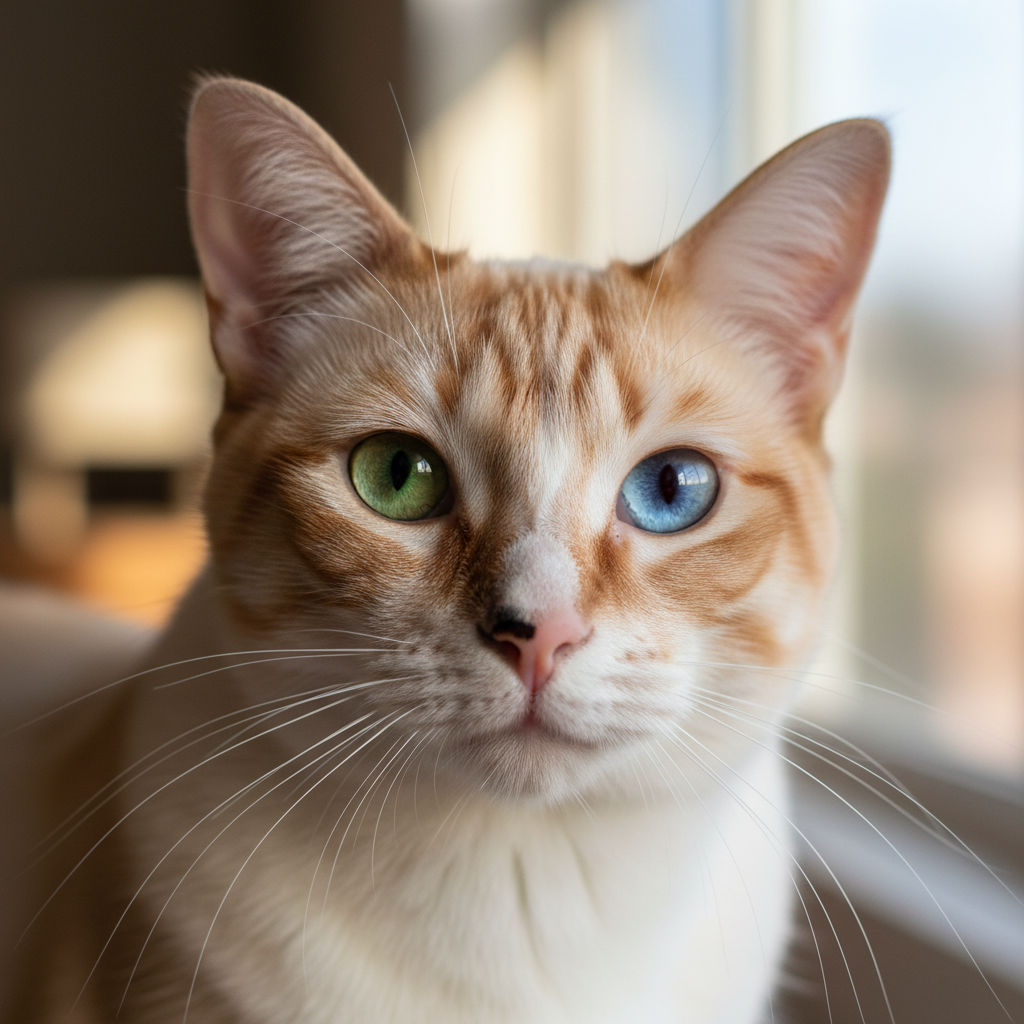

In [20]:
import PIL
montey_hall_image = PIL.Image.open("montey_hall.png")
montey_hall_image

In [21]:
prompt="""
    Run a simulation of the Monty Hall Problem with 1,000 trials.

    The answer has always been a little difficult for me to understand when people
    solve it with math - so run a simulation with Python to show me what the
    best strategy is.
"""
result = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        prompt,
        montey_hall_image
    ],
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

display_code_execution_result(result)

---

Total trials: 1000
Wins if you stay: 318 (31.8%)
Wins if you switch: 682 (68.2%)


---

The simulation confirms the counter-intuitive truth of the Monty Hall Problem: **switching is the superior strategy.**

I ran 1,000 trials of the game, and here are the results:

*   **Wins by Staying:** 318 (~31.8%)
*   **Wins by Switching:** 682 (~68.2%)

As you can see, you are roughly **twice as likely to win** if you choose to switch doors.

### Why does this happen? (The "Non-Math" Explanation)

The best way to understand this without complex formulas is to think about your **first choice**:

1.  **If you stay:** You only win if your very first pick was the car. Since there are 3 doors, you have a **1/3 chance** of picking the car at the start. Staying preserves those original odds.
2.  **If you switch:** You win if your very first pick was a **goat**. Since there are 2 goats and only 1 car, you have a **2/3 chance** of picking a goat at the start. 

Here is the "magic" part: If you picked a goat first (which happens 66% of the time), Monty Hall **must** open the door with the other goat. This means the only remaining closed door **must** contain the car. Therefore, every time you start by picking a goat and then switch, you win the car. Since you pick a goat 2/3 of the time, switching wins 2/3 of the time!

---

## Streaming

Streaming is compatible with code execution, and you can use it to deliver a response in real time as it gets generated. Just note that successive parts of the same type (`text`, `executable_code` or `execution_result`) are meant to be joined together, and you have to stitch the output together yourself:

In [22]:
result = client.models.generate_content_stream(
    model=MODEL_ID,
    contents=[
        prompt,
        montey_hall_image
    ],
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

for chunk in result:
  display_code_execution_result(chunk)

---

---

Total Trials: 1000
Wins by staying: 328 (32.80%)
Wins by switching: 672 (67.20%)


---

Based on the simulation of 1,000

...

'll be wrong more often than not!

(And while it's not a goat or a car, your heter

---

ochromatic cat mascot definitely seems to approve of these odds!)

---

---

## Next Steps
### Useful API references:

Check the [Code execution documentation](https://ai.google.dev/gemini-api/docs/code-execution) for more details about the feature and in particular, the [recommendations](https://ai.google.dev/gemini-api/docs/code-execution?lang=python#code-execution-vs-function-calling) regarding when to use it instead of [function calling](https://ai.google.dev/gemini-api/docs/function-calling).

### Continue your discovery of the Gemini API

Please check other guides from the [Cookbook](https://github.com/google-gemini/cookbook/) for further examples on how to use Gemini and in particular [this example](../quickstarts/Get_started_LiveAPI_tools.ipynb) showing how to use the different tools (including code execution) with the Live API.

The [Search grounding](./Search_Grounding.ipynb) guide also has an example mixing grounding and code execution that is worth checking.

To see how code execution is used with Gemini 1.5, please take a look at the [legacy code execution example](https://github.com/google-gemini/cookbook/blob/gemini-1.5-archive/quickstarts/Code_Execution.ipynb).